# Laptop benchmark: C++ vs Python vs R vs JavaScript

How four languages use a computer's **CPU, RAM and GPU**, measured with one shared set of tests
(`common/SPEC.md`). Each language runs the same algorithms on the same inputs; the GPU tests run the
same OpenCL kernels from C++, Python and R; JavaScript (Node.js) runs a line-by-line WebGPU translation of them.

**Before running this notebook**, produce results with `./run_all.sh` (Linux) or `run_all.cmd` (Windows), all four
languages, or one language at a time with `--langs cpp` / `python` / `r` / `js`. Then *Run All*.

How to read the numbers:
- **rate** = work per second, higher is better (e.g. M iter/s, GB/s, GFLOP/s).
- **× C++** = a language's rate divided by C++'s rate on the same test (1× = as fast as C++, 0.1× = ten times slower).
- Loop-style tests use smaller sizes in Python and R (they are slower), but rates don't depend on size, so they are comparable.
- Python (NumPy), R and JavaScript (through `koffi`) all call a BLAS library for `matmul_blas`, like C++ (OpenBLAS,
  except R on Windows, which ships a single-threaded reference BLAS).
- If a language skips a test, its averages only include the tests it ran.

In [1]:
# ---- Settings (edit these) -------------------------------------------------------------
import os
from pathlib import Path

RESULTS = Path(os.environ.get("BENCH_RESULTS", "results"))  # one sub-folder per machine; relative to this notebook
MACHINE = os.environ.get("BENCH_VIEW_MACHINE") or None  # machine to analyse in detail (its folder name);
                                                        # None = the machine with the newest run
MODE = os.environ.get("BENCH_MODE", "full")  # "full", "quick" or "verify"; falls back to the newest mode found
BATCH = None      # e.g. "20261001-140000" to analyse one run_all.sh invocation only;
                  # None = newest run of each language (lets you run languages one at a time)

# Theoretical peaks are worked out per machine from results/<machine>/system_<batch>.csv (CPU flags,
# clock - measured by Cpp/hw_probe where the OS does not report it -, cores, RAM type/speed/modules, GPU compute
# units and memory bus), with the optional, hand-written results/<machine>/hardware.csv on top.
# If a guess is wrong, correct it here, e.g.
#   PEAK_OVERRIDES = {"my-desktop": {"ram_channels": 4, "cpu_fp64_flop_per_cycle": 32, "gpu_lanes_per_cu": 128}}
PEAK_OVERRIDES = {}

In [2]:
import glob, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

# Chart style: light surface, hairline solid grid, recessive axes, thin marks.
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
LANGS = ["C++", "Python", "R", "JavaScript"]
COLORS = {"C++": "#2a78d6", "Python": "#eb6834", "R": "#1baf7a", "JavaScript": "#eda100"}  # fixed per language
# Four hues pass the colour-vision checks for bars and lines (neighbours only), not for scatter plots,
# so the one scatter chart is split into one panel per language, and lines carry name labels.
PHASE_NAMES = {"cpp": "C++", "python": "Python", "r": "R", "js": "JavaScript"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Cantarell", "Noto Sans", "DejaVu Sans"], "font.size": 9.5,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "legend.labelcolor": INK2,
    "lines.linewidth": 2, "lines.markersize": 6, "axes.unicode_minus": False,
})

# Display unit for each work unit, so every chart of one unit shares an axis.
DISPLAY = {"FLOP": (1e9, "GFLOP/s"), "B": (1e9, "GB/s"), "access": (1e6, "M accesses/s"),
           "px": (1e6, "M px/s"), "iter": (1e6, "M iter/s"), "call": (1e6, "M calls/s"),
           "elem": (1e6, "M elem/s"), "item": (1e6, "M items/s"), "op": (1e6, "M ops/s")}

def fmt(v, digits=3):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return "-"
    return f"{v:.{digits}g}" if abs(v) < 10 ** digits else f"{v:,.0f}"

def legend_handles(langs):
    return [plt.Line2D([], [], color=COLORS[l], lw=6, label=l) for l in langs]

def hbar_groups(ax, groups, langs, value_of, label_of=None, log=False):
    # Horizontal grouped bars: one group per entry of `groups`, one thin bar per language.
    h = 0.62 / max(len(langs), 1)
    for gi, g in enumerate(groups):
        for li, lang in enumerate(langs):
            v = value_of(g, lang)
            if v is None or not np.isfinite(v) or v <= 0:
                continue
            y = gi + (li - (len(langs) - 1) / 2) * h
            ax.barh(y, v, height=h, color=COLORS[lang], edgecolor=SURFACE, linewidth=1.5)
            ax.text(v, y, "  " + (label_of(g, lang, v) if label_of else fmt(v)),
                    va="center", ha="left", fontsize=8, color=INK2)
    ax.set_yticks(range(len(groups)), groups)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    if log:
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.margins(x=0.25)

def end_label(ax, x, y, text, color=INK2):
    # Label at the end of a line; finish_layout() moves apart labels that would overlap.
    ax.annotate(text, xy=(x, y), xytext=(5, 0), textcoords="offset points", ha="left", va="center",
                fontsize=8, color=color, gid="end-label", annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color=AXIS, lw=0.8, relpos=(0, 0.5), shrinkA=1, shrinkB=4))

def spread_end_labels(ax):
    # Labels closer than one text line are spread evenly around their mean height and joined to
    # their line end by a thin leader. Works in pixels, so it must run after the layout is final.
    labels = [t for t in ax.texts if t.get_gid() == "end-label"]
    if not labels:
        return
    px = ax.figure.dpi / 72                       # pixels per point
    gap = 8 * 1.4 * px                            # one line of 8 pt text
    anchor = {t: ax.transData.transform(t.xy)[1] for t in labels}
    clusters = [[t] for t in sorted(labels, key=anchor.get)]

    def heights(c):
        mid = np.mean([anchor[t] for t in c])
        return [mid + (k - (len(c) - 1) / 2) * gap for k in range(len(c))]

    k = 0
    while k < len(clusters) - 1:
        if heights(clusters[k])[-1] + gap > heights(clusters[k + 1])[0] + 0.5:
            clusters[k:k + 2] = [clusters[k] + clusters[k + 1]]
            k = max(k - 1, 0)                     # the merged cluster grew; recheck the one below
        else:
            k += 1
    for c in clusters:
        for t, y in zip(c, heights(c)):
            dy = (y - anchor[t]) / px
            moved = abs(dy) > 1
            t.xyann = (12 if moved else 5, dy)
            t.arrow_patch.set_visible(moved)

def finish_layout(fig, langs=()):
    # One legend for the whole figure, in its own row above every panel title, right-aligned, so it
    # never covers a title or data; then lay out the panels and spread end-of-line labels.
    rect = (0, 0, 1, 1)
    if len(langs):
        leg = fig.legend(handles=legend_handles(langs), loc="upper right", bbox_to_anchor=(1, 1),
                         ncols=len(langs), borderaxespad=0.2, handlelength=1.2)
        h = leg.get_window_extent(fig.canvas.get_renderer()).height / fig.bbox.height
        rect = (0, 0, 1, 1 - h)
    fig.tight_layout(rect=rect)
    for ax in fig.axes:
        spread_end_labels(ax)

def peak_line(ax, x, text):
    # Reference line for a theoretical peak, labelled at the bottom.
    if x is None or not np.isfinite(x):
        return
    ax.axvline(x, color=AXIS, lw=1)
    ax.text(x, 0.02, f"{text} ", transform=ax.get_xaxis_transform(), color=MUTED, fontsize=8,
            ha="right", va="bottom")

## 1. Load results
Reads every machine under `results/`. Sections 2–11 analyse one machine (`MACHINE`): the newest run of each
language for the chosen mode (or one batch, if `BATCH` is set). Section 12 compares machines.

In [3]:
def read_kv(path):
    m = pd.read_csv(path, dtype=str, keep_default_na=False)
    return dict(zip(m["key"], m["value"]))

def read_results(root):
    # Every <run_id>.csv under root (any depth) with its _meta.csv; machine = meta value or folder name.
    frames, metas = [], {}
    for path in sorted(Path(root).rglob("*.csv")):
        if path.name.startswith(("sensors_", "system_")) or path.name.endswith("_meta.csv"):
            continue
        d = pd.read_csv(path, dtype={"batch": str})
        if d.empty or "run_id" not in d:
            continue
        meta_path = path.with_name(path.stem + "_meta.csv")
        m = read_kv(meta_path) if meta_path.exists() else {}
        rel = path.relative_to(root)
        d["machine"] = m.get("machine") or (rel.parts[0] if len(rel.parts) > 1 else "unknown")
        d["run_key"] = d["machine"] + "/" + d["run_id"]
        d["folder"] = str(path.parent)
        frames.append(d)
        metas[d.run_key.iloc[0]] = m
    if not frames:
        raise SystemExit(f"No results in {Path(root).resolve()} - run ./run_all.sh first.")
    return pd.concat(frames, ignore_index=True), metas

def read_systems(root):
    # {machine: [system snapshot dicts, oldest first]} from system_<batch>.csv written by run_all.sh
    systems = {}
    for path in sorted(Path(root).rglob("system_*.csv")):
        d = read_kv(path)
        systems.setdefault(d.get("machine") or path.parent.name, []).append(d)
    return systems

rows, metas = read_results(RESULTS)
systems = read_systems(RESULTS)
runs = rows.groupby("run_key").agg(machine=("machine", "first"), run_id=("run_id", "first"),
                                   language=("language", "first"), mode=("mode", "first"),
                                   batch=("batch", "first"), tests=("test", "nunique")).reset_index()
runs["started"] = runs.run_id.str.split("_").str[-1]
machine = MACHINE or runs.sort_values("started").machine.iloc[-1]
if machine not in set(runs.machine):
    raise SystemExit(f"No results for machine '{machine}'. Available: {sorted(set(runs.machine))}")
here = runs[runs.machine == machine]
if BATCH:
    here = here[here.batch == str(BATCH)]
mode = MODE if (here["mode"] == MODE).any() else here.sort_values("started")["mode"].iloc[-1]
if mode != MODE:
    print(f"No '{MODE}' runs found for {machine} - using the newest mode available: '{mode}'.")
chosen = here[here["mode"] == mode].sort_values("started").groupby("language").tail(1)
data = rows[rows.run_key.isin(chosen.run_key)].copy()
langs = [l for l in LANGS if l in set(data.language)]
REF = "C++" if "C++" in langs else langs[0]          # reference language for "x C++" ratios

tests_spec = pd.read_csv(RESULTS.parent / "common" / "tests.csv") if (RESULTS.parent / "common" / "tests.csv").exists() \
    else pd.read_csv("common/tests.csv")
TEST_ORDER = list(tests_spec.test)
CATEGORIES = ["cpu_single", "cpu_multi", "ram", "gpu"]
CAT_TITLES = {"cpu_single": "CPU, single core", "cpu_multi": "CPU, all cores", "ram": "RAM", "gpu": "GPU"}

print(f"Machines with results: {', '.join(sorted(set(runs.machine)))}")
print(f"Analysing: {machine}  (mode: {mode})")
if mode == "verify":
    print("Note: verify-mode sizes are tiny; rates are not meaningful (use it to check correctness only).")
display(chosen[["language", "run_id", "batch", "mode", "tests"]].set_index("language").loc[langs])

Machines with results: alienware-m16-r1, dell-inc-inspiron-14-7425-2-in-1
Analysing: alienware-m16-r1  (mode: full)


,run_id,batch,mode,tests
language,,,,
C++,cpp_20261001-205737,20261001-205732,full,18
Python,python_20261001-205902,20261001-205732,full,18
R,r_20261001-210029,20261001-205732,full,18
JavaScript,js_20261001-210616,20261001-205732,full,18


## 2. The machine and each run

In [4]:
def system_of(m, batches=()):
    # The machine's system snapshot (the one from one of `batches` if present, else its newest), with the
    # values of the optional, hand-written results/<machine>/hardware.csv applied on top.
    snaps = systems.get(m, [])
    snap = dict(next((d for d in reversed(snaps) if d.get("batch") in batches), snaps[-1] if snaps else {}))
    # measured clocks depend on the load at that moment: the highest any snapshot of the machine recorded
    for k in ("cpu_max_mhz", "cpu_e_max_mhz", "gpu_clock_max_logged_mhz"):
        vals = [num(d.get(k)) for d in snaps if np.isfinite(num(d.get(k)))]
        if vals:
            snap[k] = f"{max(vals):.0f}"
    hw = RESULTS / m / "hardware.csv"
    return {**snap, **{k: v for k, v in read_kv(hw).items() if v}} if hw.exists() else snap

def num(x, default=np.nan):
    try:
        return float(x)
    except (TypeError, ValueError):
        return default

def machine_peaks(m, sysinfo, meta_list):
    # Theoretical peaks for machine m, from its system snapshot and run metadata (guesses explained).
    o = PEAK_OVERRIDES.get(m, {})
    first = lambda key: next((x[key] for x in meta_list if x.get(key) not in (None, "")), "")
    cpu = sysinfo.get("cpu") or first("cpu")
    flags = set(sysinfo.get("cpu_flags", "").split())
    phys = num(sysinfo.get("physical_cores"), num(first("physical_cores"), 1))
    p_cores, e_cores = num(sysinfo.get("performance_cores")), num(sysinfo.get("efficiency_cores"), 0)
    ghz, e_ghz = num(sysinfo.get("cpu_max_mhz")) / 1000, num(sysinfo.get("cpu_e_max_mhz")) / 1000
    if "avx512f" in flags and "intel" in cpu.lower():
        fpc, why = 32, "AVX-512 with two FMA units"
    elif {"avx2", "fma"} <= flags:
        fpc, why = 16, "AVX2: two 256-bit FMA units"
    elif "avx" in flags or "asimd" in flags:
        fpc, why = 8, "128/256-bit SIMD"
    else:
        fpc, why = 4, "no wide SIMD flags found"
    fpc = o.get("cpu_fp64_flop_per_cycle", fpc)
    ram_type = sysinfo.get("ram_type", "")
    mts = o.get("ram_mts", num(sysinfo.get("ram_speed_mts")))
    modules = int(num(sysinfo.get("ram_modules"), 0))
    channels = o.get("ram_channels", 2 if ram_type.startswith("LPDDR") or modules >= 2 else max(modules, 1))
    gpu = first("gpu_device")
    lanes = o.get("gpu_lanes_per_cu", 128 if re.search(r"nvidia|geforce|rtx|quadro", gpu, re.I)
                  else 8 if re.search(r"intel|iris|uhd|arc", gpu, re.I) else 64)
    cus = num(first("gpu_compute_units"))
    # the GPU may boost above the clock its driver reports: the highest clock the sensor log saw counts if higher
    mhz = max((v for v in (num(first("gpu_max_clock_mhz")), num(sysinfo.get("gpu_clock_max_logged_mhz")),
                           num(sysinfo.get("gpu_max_clock_mhz"))) if np.isfinite(v)), default=np.nan)
    hybrid = np.isfinite(p_cores) and e_cores > 0 and np.isfinite(e_ghz)
    discrete = bool(re.search(r"nvidia|geforce|rtx|gtx|quadro|radeon rx|radeon pro|arc a\d", gpu, re.I))
    ram_gbs = mts * 1e6 * 8 * channels / 1e9
    peaks = {"cpu_fp64_gflops": (p_cores * fpc * ghz + e_cores * fpc / 2 * e_ghz) if hybrid else phys * fpc * ghz,
             "ram_gbs": ram_gbs,
             "gpu_fp32_gflops": cus * lanes * 2 * mhz / 1e3,
             # an integrated GPU uses system RAM; a discrete GPU's own memory comes from hardware.csv
             "gpu_mem_gbs": o.get("gpu_memory_gbs", num(sysinfo.get("gpu_memory_gbs"))) if discrete else ram_gbs}
    cpu_why = (f"{p_cores:.0f} P-cores x {fpc} FLOP/cycle x {ghz:.2f} GHz + {e_cores:.0f} E-cores x {fpc // 2} FLOP/cycle x {e_ghz:.2f} GHz ({why})"
               if hybrid else f"{phys:.0f} cores x {fpc} FLOP/cycle ({why}) x {ghz:.2f} GHz")
    explain = {
        "CPU FP64 peak (GFLOP/s)": (f"{peaks['cpu_fp64_gflops']:.0f} = {cpu_why}" if np.isfinite(peaks["cpu_fp64_gflops"])
                                    else "unknown (no maximum clock: Windows does not report it; add cpu_max_mhz to hardware.csv)"),
        "RAM bandwidth peak (GB/s)": (f"{peaks['ram_gbs']:.1f} = {mts:.0f} MT/s x 8 B x {channels} channels ({ram_type or '?'}, {modules} modules)"
                                      if np.isfinite(mts) else "unknown (RAM speed not in the system snapshot; set PEAK_OVERRIDES)"),
        "GPU FP32 peak (GFLOP/s)": (f"{peaks['gpu_fp32_gflops']:.0f} = {cus:.0f} compute units x {lanes} lanes x 2 x {mhz:.0f} MHz"
                                    if np.isfinite(peaks["gpu_fp32_gflops"]) else "unknown (no OpenCL GPU results)"),
        "GPU memory peak (GB/s)": (("unknown (discrete GPU: no gpu_memory_gbs in the system snapshot; add it to hardware.csv)" if not np.isfinite(peaks["gpu_mem_gbs"])
                                    else f"{peaks['gpu_mem_gbs']:.0f} (discrete GPU: memory bus from the CUDA driver, in the system snapshot)") if discrete
                                   else f"{peaks['gpu_mem_gbs']:.1f} (integrated GPU: the RAM peak)"),
    }
    return peaks, explain

run_meta = {l: metas.get(chosen.set_index("language").run_key[l], {}) for l in langs}
SYSTEM = system_of(machine, set(chosen.batch))
if SYSTEM:
    keys = ["machine", "vendor", "product", "cpu", "cpu_max_mhz", "physical_cores", "performance_cores", "efficiency_cores",
            "logical_cpus", "cpu_flags",
            "l3_cache", "ram_gib", "ram_type", "ram_speed_mts", "ram_modules", "gpus", "opencl_devices", "os", "kernel",
            "power", "platform_profile", "governor", "transparent_hugepages", "suite_commit", "suite_tests_sha"]
    display(pd.Series({k: SYSTEM.get(k, "") or "-" for k in keys}, name=machine).to_frame())
else:
    print("No system snapshot for this machine (runs were not started with run_all.sh); peaks use run metadata only.")

KEYS = ["language_version", "build", "blas", "numpy_version", "gpu_device", "gpu_driver", "gpu_compute_units",
        "gpu_max_clock_mhz", "cpu_temp_start_c", "cpu_temp_end_c", "elapsed_s", "skipped", "failed"]
meta = pd.DataFrame(run_meta).reindex(KEYS).replace("", "-").fillna("-")
with pd.option_context("display.max_colwidth", 70):
    display(meta)

PEAK, peak_explain = machine_peaks(machine, SYSTEM, list(run_meta.values()))
PHYS = int(num(SYSTEM.get("physical_cores"), num(next((x.get("physical_cores") for x in run_meta.values()), 1), 1)))
LOGICAL = int(num(SYSTEM.get("logical_cpus"), num(next((x.get("logical_cpus") for x in run_meta.values()), 1), 1)))
display(pd.Series(peak_explain, name="theoretical peak (correct with PEAK_OVERRIDES)").to_frame())

,alienware-m16-r1
machine,alienware-m16-r1
vendor,Alienware
product,Alienware m16 R1
cpu,13th Gen Intel(R) Core(TM) i9-13900HX
cpu_max_mhz,5283
physical_cores,24
performance_cores,8
efficiency_cores,16
logical_cpus,32
cpu_flags,sse4_2 avx avx2 fma


,C++,Python,R,JavaScript
language_version,g++ 14.2.0,CPython 3.13.3,R 4.5.2,Node.js v22.14.0 (V8 12.4.254.21-node.22)
build,"g++ -O3 -march=native -ffp-contract=off -std=c++20 -pthread -Wa,-m...",C:\Python313\python.exe,C:/PROGRA~1/R/R-4.5.2,C:\Program Files\nodejs\node.exe --expose-gc
blas,OpenBLAS 0.3.34 DYNAMIC_ARCH NO_AFFINITY Haswell MAX_THREADS=64,scipy-openblas: OpenBLAS 0.3.28 USE64BITINT DYNAMIC_ARCH NO_AFFIN...,C:\Program Files\R\R-4.5.2\bin\x64\Rblas.dll,OpenBLAS 0.3.34 DYNAMIC_ARCH NO_AFFINITY Haswell MAX_THREADS=64 (v...
numpy_version,-,2.2.5,-,-
gpu_device,NVIDIA GeForce RTX 4090 Laptop GPU,NVIDIA GeForce RTX 4090 Laptop GPU,NVIDIA GeForce RTX 4090 Laptop GPU,nvidia-geforce-rtx-4090-laptop-gpu
gpu_driver,596.08,596.08,596.08,D3D12 driver version 32.0.15.9608
gpu_compute_units,76,76,76,-
gpu_max_clock_mhz,1950,1950,1950,-
cpu_temp_start_c,-,-,-,-
cpu_temp_end_c,-,-,-,-


,theoretical peak (correct with PEAK_OVERRIDES)
CPU FP64 peak (GFLOP/s),1174 = 8 P-cores x 16 FLOP/cycle x 5.28 GHz + ...
RAM bandwidth peak (GB/s),"83.2 = 5200 MT/s x 8 B x 2 channels (DDR5, 2 m..."
GPU FP32 peak (GFLOP/s),46986 = 76 compute units x 128 lanes x 2 x 241...
GPU memory peak (GB/s),576 (discrete GPU: memory bus from the CUDA dr...


## 3. Overall: how close each language gets to C++

For every test, each language's best rate (fastest thread count / size) is divided by C++'s.
A category score is the geometric mean of its tests; **Overall** is the geometric mean of the categories
(each category counts equally). The log scale keeps 0.01× and 1× readable on one axis.

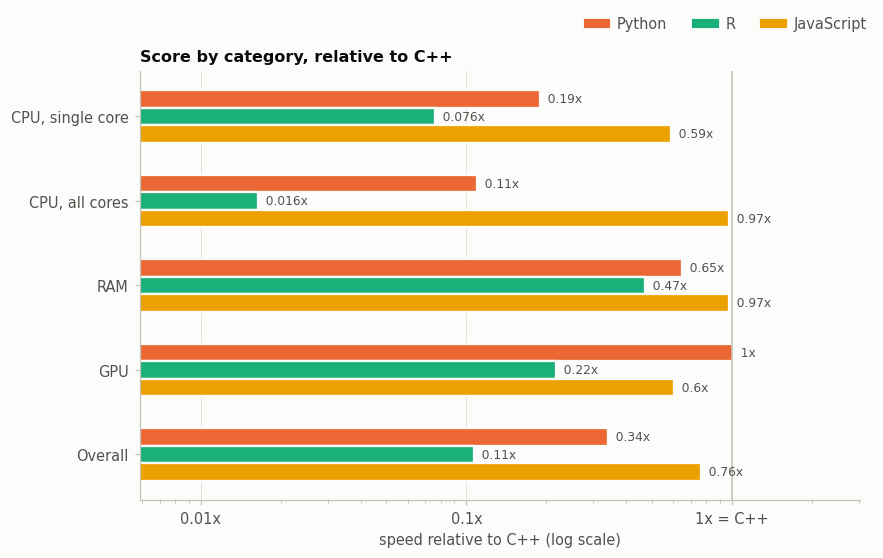

language,C++,Python,R,JavaScript
"CPU, single core",1x,0.19x,0.0761x,0.591x
"CPU, all cores",1x,0.11x,0.0165x,0.969x
RAM,1x,0.65x,0.469x,0.972x
GPU,1x,1.01x,0.218x,0.602x
Overall,1x,0.342x,0.106x,0.761x


In [5]:
med = (data.groupby(["language", "category", "test", "style", "unit", "threads", "size"], as_index=False)
           .agg(seconds=("seconds", "median"), rate=("rate", "median"), reps=("rate", "size"),
                cv=("rate", lambda r: r.std(ddof=0) / r.mean() if len(r) > 1 else np.nan)))
best = med.loc[med.groupby(["language", "test"]).rate.idxmax()]
rate_by = best.pivot(index="test", columns="language", values="rate")
rate_by = rate_by.reindex([t for t in TEST_ORDER if t in rate_by.index])[langs]
ratio = rate_by.div(rate_by[REF], axis=0)
test_cat = tests_spec.set_index("test").category

def gmean(s):
    s = s.dropna()
    return float(np.exp(np.log(s).mean())) if len(s) else np.nan

cat_score = pd.DataFrame({c: ratio[test_cat.reindex(ratio.index) == c].apply(gmean) for c in CATEGORIES}).T
cat_score = cat_score.dropna(how="all")
overall = cat_score.apply(gmean)
scores = pd.concat([cat_score, overall.to_frame("overall").T])
labels = [CAT_TITLES.get(c, "Overall") for c in scores.index]

others = [l for l in langs if l != REF]   # REF is 1x by definition: drawn as the reference line
fig, ax = plt.subplots(figsize=(8, 0.5 * len(scores) * max(len(others), 2) / 2 + 1.3))
hbar_groups(ax, list(scores.index), others, lambda g, l: scores.loc[g, l],
            label_of=lambda g, l, v: f"{v:.2g}x", log=True)
ax.set_yticklabels(labels)
ax.set_xlim(right=max(2, np.nanmax(scores[others].values) * 3) if others else 2)
ax.axvline(1, color=AXIS, lw=1)
ax.set_xlabel(f"speed relative to {REF} (log scale)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"1x = {REF}" if v == 1 else f"{v:g}x"))
ax.set_title(f"Score by category, relative to {REF}")
finish_layout(fig, others); plt.show()

display(scores.rename(index=dict(zip(scores.index, labels))).map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-"))

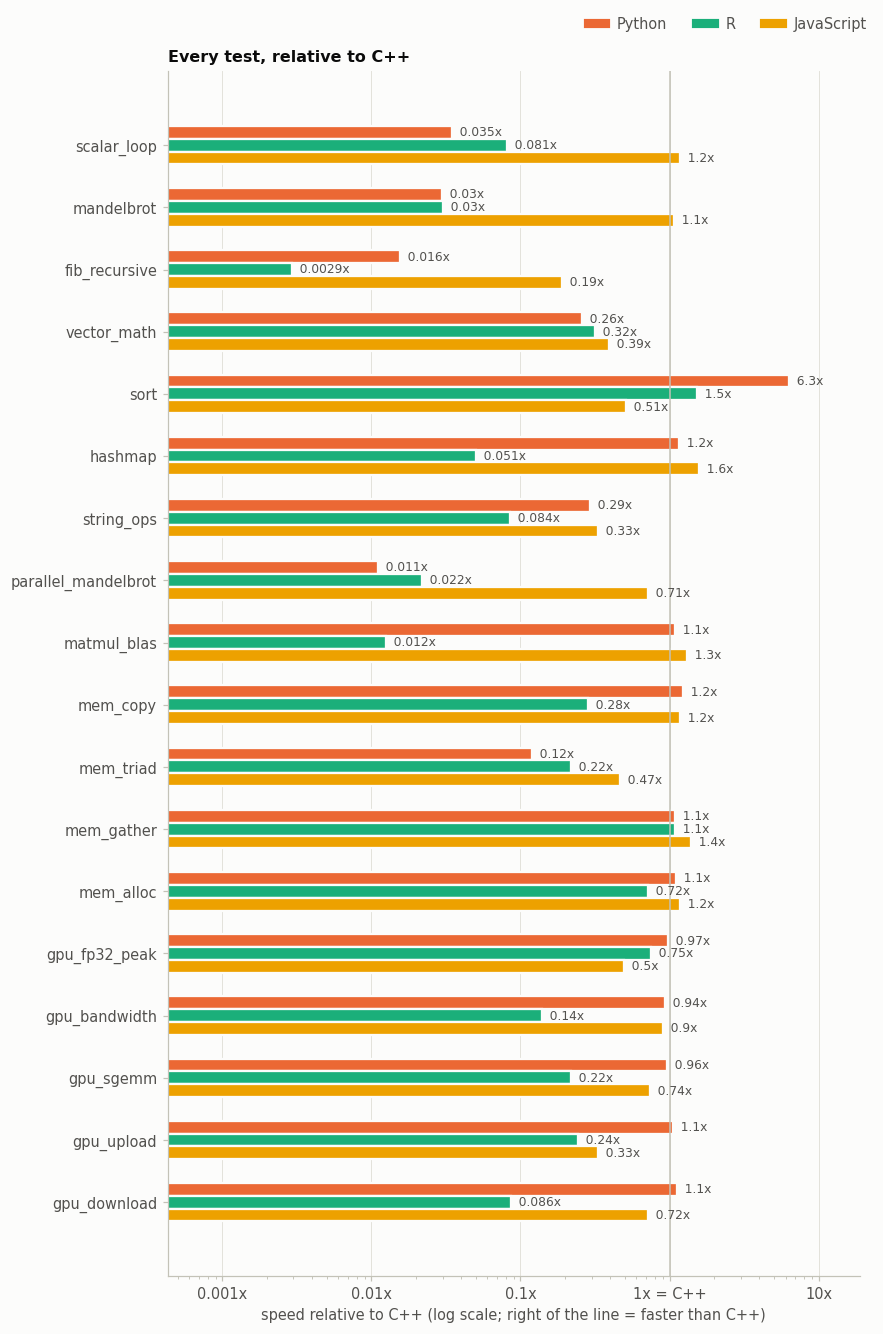

In [6]:
# Every test: speed relative to C++ (same data as above, before averaging)
fig, ax = plt.subplots(figsize=(8, 0.4 * len(ratio) * max(len(others), 2) / 2 + 1.3))
hbar_groups(ax, list(ratio.index), others, lambda g, l: ratio.loc[g, l],
            label_of=lambda g, l, v: f"{v:.2g}x", log=True)
ax.set_xlim(right=max(2, np.nanmax(ratio[others].values) * 3) if others else 2)
ax.axvline(1, color=AXIS, lw=1)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"1x = {REF}" if v == 1 else f"{v:g}x"))
ax.set_xlabel(f"speed relative to {REF} (log scale; right of the line = faster than {REF})")
ax.set_title(f"Every test, relative to {REF}")
finish_layout(fig, others); plt.show()

## 4. CPU, single core

Each panel is one test with its own unit. *loop* tests are plain code in each language;
*vectorized* / *builtin* tests hand the work to optimised library code (NumPy, R's C internals, the C++ standard library).

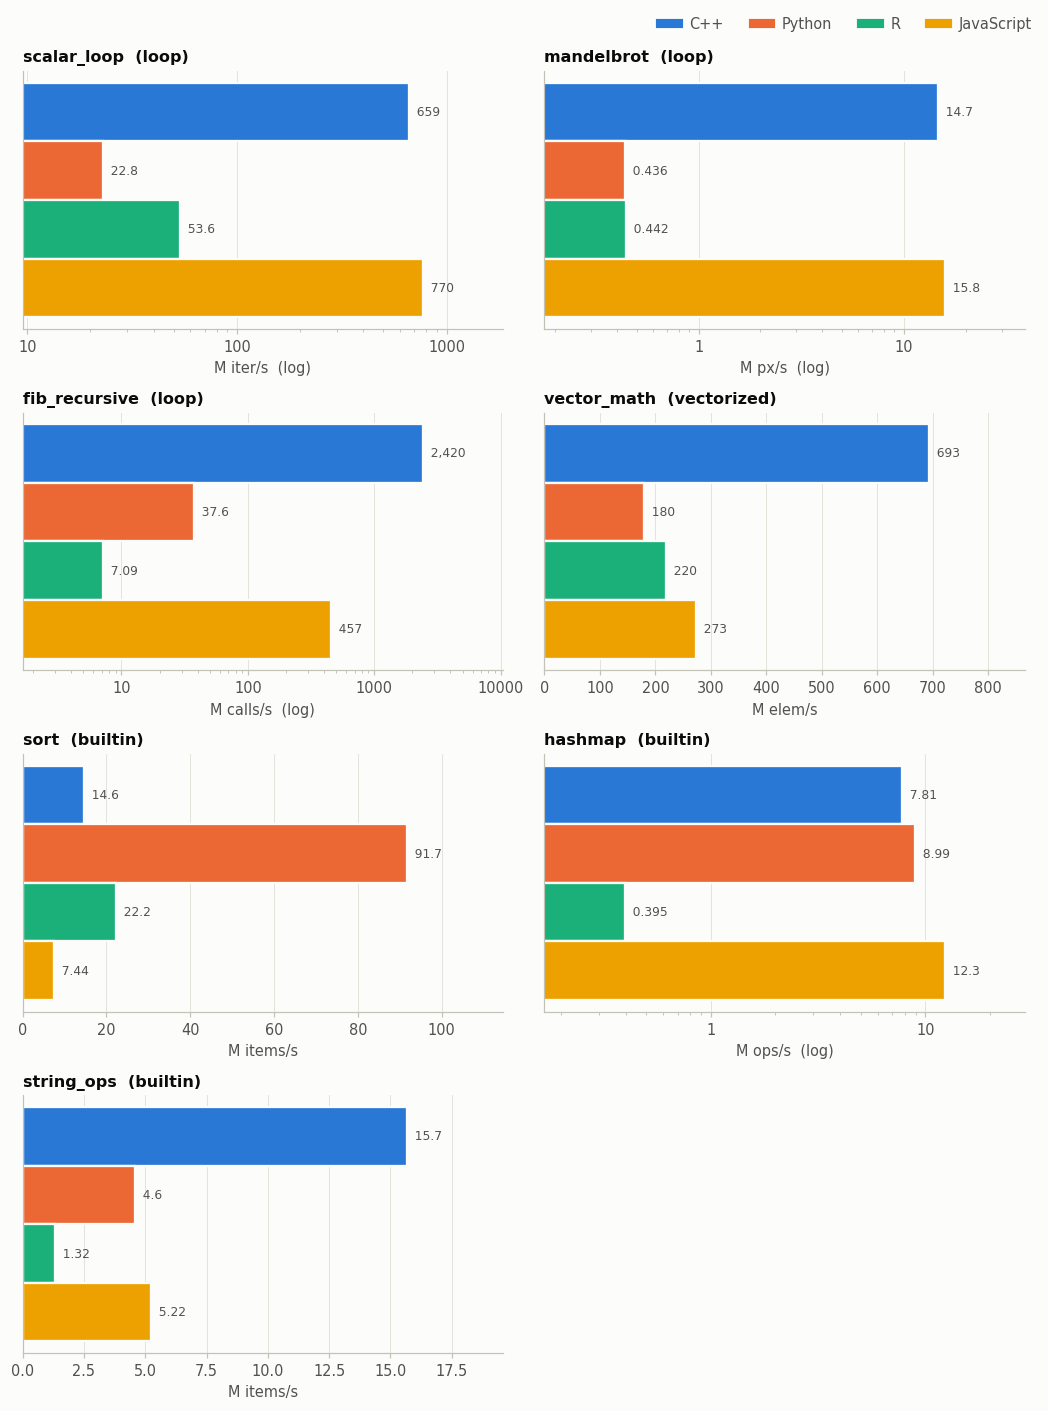

,unit,C++,Python,R,JavaScript,Python xC++,R xC++,JavaScript xC++
test,,,,,,,,
scalar_loop,M iter/s,659,22.8,53.6,770,0.0347,0.0813,1.17
mandelbrot,M px/s,14.7,0.436,0.442,15.8,0.0297,0.0301,1.08
fib_recursive,M calls/s,"2,420",37.6,7.09,457,0.0156,0.00293,0.189
vector_math,M elem/s,693,180,220,273,0.26,0.318,0.394
sort,M items/s,14.6,91.7,22.2,7.44,6.29,1.52,0.51
hashmap,M ops/s,7.81,8.99,0.395,12.3,1.15,0.0506,1.57
string_ops,M items/s,15.7,4.6,1.32,5.22,0.294,0.0845,0.333


In [7]:
def test_panels(tests, ncols=2, log_if_spread=30):
    tests = [t for t in tests if t in rate_by.index]
    if not tests:
        print("No results for these tests.")
        return
    nrows = math.ceil(len(tests) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(9.5, 1.15 * nrows * max(len(langs), 2) / 2 + 0.9 * nrows),
                             squeeze=False)
    for ax, t in zip(axes.flat, tests):
        unit = tests_spec.set_index("test").unit[t]
        scale, label = DISPLAY[unit]
        vals = {l: rate_by.loc[t, l] / scale for l in langs if np.isfinite(rate_by.loc[t, l])}
        spread = max(vals.values()) / min(vals.values()) if vals else 1
        hbar_groups(ax, [t], langs, lambda g, l: vals.get(l, np.nan), log=spread > log_if_spread)
        style = tests_spec.set_index("test")["style"][t]
        ax.set_title(f"{t}  ({style})")
        ax.set_yticks([])
        ax.set_xlabel(label + ("  (log)" if spread > log_if_spread else ""))
    for ax in axes.flat[len(tests):]:
        ax.set_visible(False)
    finish_layout(fig, langs); plt.show()

def rate_table(tests):
    rows_ = []
    for t in [t for t in tests if t in rate_by.index]:
        scale, label = DISPLAY[tests_spec.set_index("test").unit[t]]
        rows_.append({"test": t, "unit": label, **{l: fmt(rate_by.loc[t, l] / scale) for l in langs},
                      **{f"{l} x{REF}": f"{ratio.loc[t, l]:.3g}" for l in langs if l != REF}})
    display(pd.DataFrame(rows_).set_index("test"))

single = [t for t in TEST_ORDER if test_cat[t] == "cpu_single"]
test_panels(single)
rate_table(single)

## 5. CPU, all cores

**Scaling**: the same Mandelbrot work split across 1 → all logical CPUs. Speedup = rate with *n* workers ÷ rate with 1.
The gray line is perfect scaling; beyond the physical cores, extra "threads" share a core (SMT) and the
laptop's power/thermal limit also caps the clock.

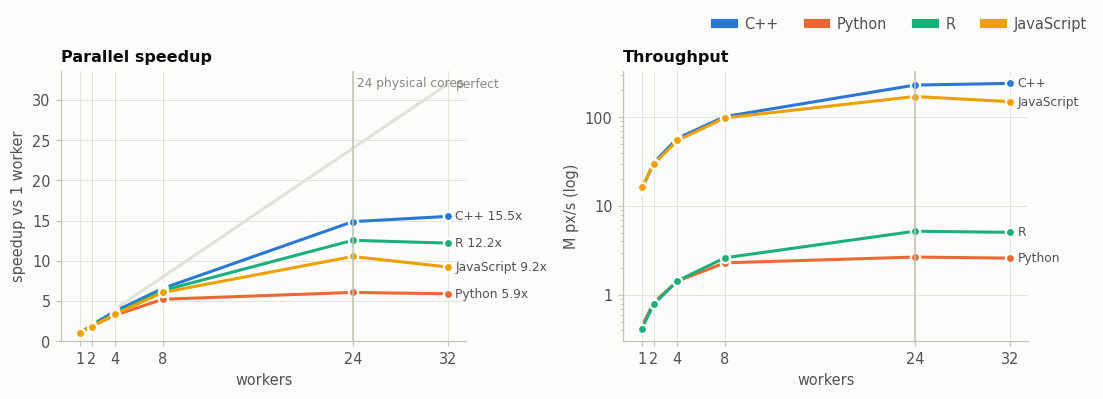

language,C++ speedup,Python speedup,R speedup,JavaScript speedup
threads,,,,
1,1.00,1.00,1.00,1.00
2,1.98,1.87,1.89,1.82
4,3.74,3.24,3.47,3.38
8,6.57,5.22,6.31,6.06
24,14.87,6.07,12.55,10.54
32,15.53,5.90,12.20,9.23


In [8]:
pm = med[med.test == "parallel_mandelbrot"].copy()
if pm.empty:
    print("No parallel_mandelbrot results.")
else:
    pm["speedup"] = pm.rate / pm.groupby("language").rate.transform(lambda r: r[pm.loc[r.index, "threads"] == 1].max())
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    ax = axes[0]
    xs = sorted(pm.threads.unique())
    ax.plot(xs, xs, color=GRID, lw=2, zorder=1)
    end_label(ax, xs[-1], xs[-1], "perfect", color=MUTED)
    for l in langs:
        d = pm[pm.language == l].sort_values("threads")
        ax.plot(d.threads, d.speedup, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d.threads.iloc[-1], d.speedup.iloc[-1], f"{l} {d.speedup.iloc[-1]:.1f}x")
    ax.axvline(PHYS, color=AXIS, lw=1)
    ax.text(PHYS, 0.98, f" {PHYS} physical cores", transform=ax.get_xaxis_transform(), color=MUTED, fontsize=8, va="top")
    ax.set_xticks(xs); ax.set_xlabel("workers"); ax.set_ylabel("speedup vs 1 worker")
    ax.set_title("Parallel speedup")
    ax.set_ylim(0, max(xs) * 1.05)

    ax = axes[1]
    for l in langs:
        d = pm[pm.language == l].sort_values("threads")
        ax.plot(d.threads, d.rate / 1e6, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d.threads.iloc[-1], d.rate.iloc[-1] / 1e6, l)
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xlabel("workers"); ax.set_ylabel("M px/s (log)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.axvline(PHYS, color=AXIS, lw=1)
    ax.set_title("Throughput")
    finish_layout(fig, langs); plt.show()
    display(pm.pivot(index="threads", columns="language", values="speedup")[langs].round(2)
              .rename(columns=lambda c: f"{c} speedup"))

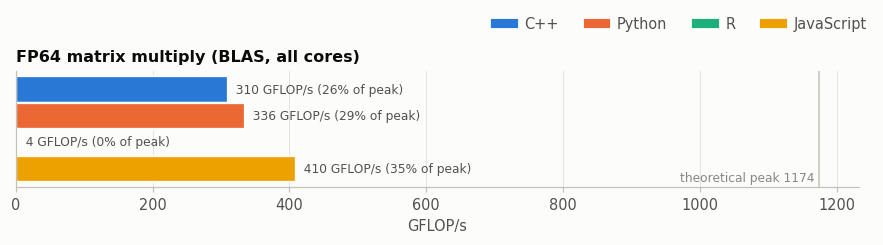

,size,threads,GFLOPs
language,,,
C++,4096.0,32,310.4
Python,4096.0,24,335.8
R,4096.0,1,3.9
JavaScript,4096.0,32,409.7


In [9]:
# Matrix multiply through BLAS (all cores) against the CPU's theoretical FP64 peak
mm = best[best.test == "matmul_blas"].set_index("language").reindex(langs)
fig, ax = plt.subplots(figsize=(8, 2.2))
hbar_groups(ax, ["matmul_blas"], langs, lambda g, l: mm.rate.get(l, np.nan) / 1e9,
            label_of=lambda g, l, v: f"{v:.0f} GFLOP/s" + (f" ({100 * v / PEAK['cpu_fp64_gflops']:.0f}% of peak)"
                                                           if np.isfinite(PEAK["cpu_fp64_gflops"]) else ""))
ax.set_yticks([]); ax.set_xlabel("GFLOP/s"); ax.set_title("FP64 matrix multiply (BLAS, all cores)")
if np.isfinite(PEAK["cpu_fp64_gflops"]):
    peak_line(ax, PEAK["cpu_fp64_gflops"], f"theoretical peak {PEAK['cpu_fp64_gflops']:.0f}")
    ax.set_xlim(0, PEAK["cpu_fp64_gflops"] * 1.05)
finish_layout(fig, langs); plt.show()
display(mm[["size", "threads", "rate"]].assign(GFLOPs=lambda d: (d.rate / 1e9).round(1)).drop(columns="rate"))

## 6. RAM

**Bandwidth** (copy and STREAM triad) against the theoretical peak of the memory. Python (NumPy) and R work on one
core; C++ also shows the triad on all physical / logical cores — a single core can't saturate the memory bus.

**Allocating big arrays**: on Linux, NumPy asks for 2 MB *huge pages* for large arrays (`madvise`), while plain C++
`new` and R use normal 4 KB pages. A kernel that gives huge pages only to programs that ask
(`/sys/kernel/mm/transparent_hugepage/enabled` = `madvise`) makes C++ and R take ~512× more page faults
when first touching new memory — that, not the language, is why NumPy wins `mem_alloc` there. Windows gives every
language 4 KB pages (its large pages need a special privilege) and zeroes each page on first touch.

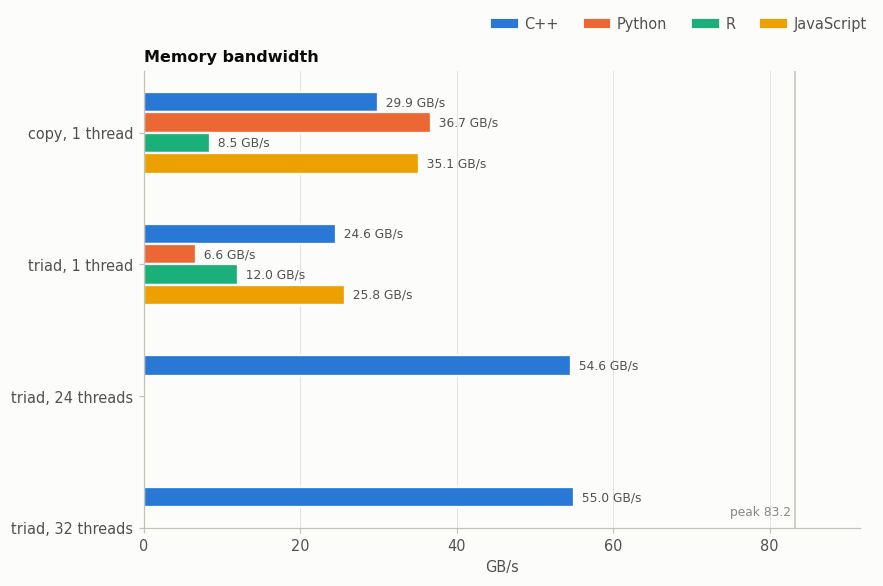

In [10]:
bw_groups = []
for t in ["mem_copy", "mem_triad"]:
    for th in sorted(med[(med.test == t)].threads.unique()):
        bw_groups.append((t, th))
bw = {(t, th, l): med[(med.test == t) & (med.threads == th) & (med.language == l)].rate.max() / 1e9
      for (t, th) in bw_groups for l in langs}
names = [f"{t.replace('mem_', '')}, {th} thread{'s' if th > 1 else ''}" for t, th in bw_groups]
if bw_groups:
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(bw_groups) * max(len(langs), 2) / 2 + 1.3))
    hbar_groups(ax, names, langs, lambda g, l: bw[bw_groups[names.index(g)] + (l,)],
                label_of=lambda g, l, v: f"{v:.1f} GB/s")
    peak_line(ax, PEAK["ram_gbs"], f"peak {PEAK['ram_gbs']:.1f}")
    ax.set_xlim(0, PEAK["ram_gbs"] * 1.1)
    ax.set_xlabel("GB/s"); ax.set_title("Memory bandwidth")
    finish_layout(fig, langs); plt.show()

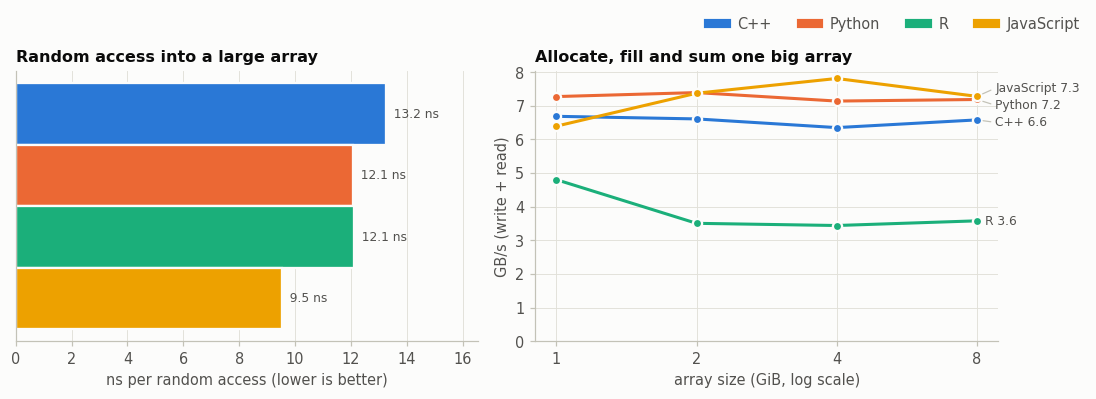

language,C++ seconds,Python seconds,R seconds,JavaScript seconds
GiB,,,,
1.0,0.32,0.30,0.45,0.34
2.0,0.65,0.58,1.23,0.58
4.0,1.35,1.20,2.50,1.10
8.0,2.61,2.39,4.80,2.36


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
g = best[best.test == "mem_gather"].set_index("language").reindex(langs)
ax = axes[0]
hbar_groups(ax, ["mem_gather"], langs, lambda _, l: 1e9 / g.rate.get(l, np.nan),
            label_of=lambda _, l, v: f"{v:.1f} ns")
ax.set_yticks([]); ax.set_xlabel("ns per random access (lower is better)")
ax.set_title("Random access into a large array")

ax = axes[1]
al = med[med.test == "mem_alloc"]
for l in langs:
    d = al[al.language == l].sort_values("size")
    if len(d):
        ax.plot(d["size"], d.rate / 1e9, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d["size"].iloc[-1], d.rate.iloc[-1] / 1e9, f"{l} {d.rate.iloc[-1] / 1e9:.1f}")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("array size (GiB, log scale)"); ax.set_ylabel("GB/s (write + read)")
ax.set_ylim(bottom=0)
ax.set_title("Allocate, fill and sum one big array")
finish_layout(fig, langs); plt.show()
display(al.pivot(index="size", columns="language", values="seconds").reindex(columns=langs).round(2)
          .rename(columns=lambda c: f"{c} seconds").rename_axis("GiB"))

## 7. GPU (OpenCL; JavaScript: WebGPU)

C++, Python and R launch the same OpenCL kernels (`common/kernels.cl`); JavaScript runs their WebGPU translation
(`common/kernels.wgsl`, same arithmetic) through Google's Dawn (Vulkan on Linux, Direct3D 12 on Windows). Differences come from how each language and API
drive the GPU: launch overhead, buffer handling, and for R the conversion between R's 64-bit numbers and the GPU's 32-bit floats.
An integrated GPU shares system RAM, so its memory peak is the RAM peak; a discrete GPU's comes from `hardware.csv`.

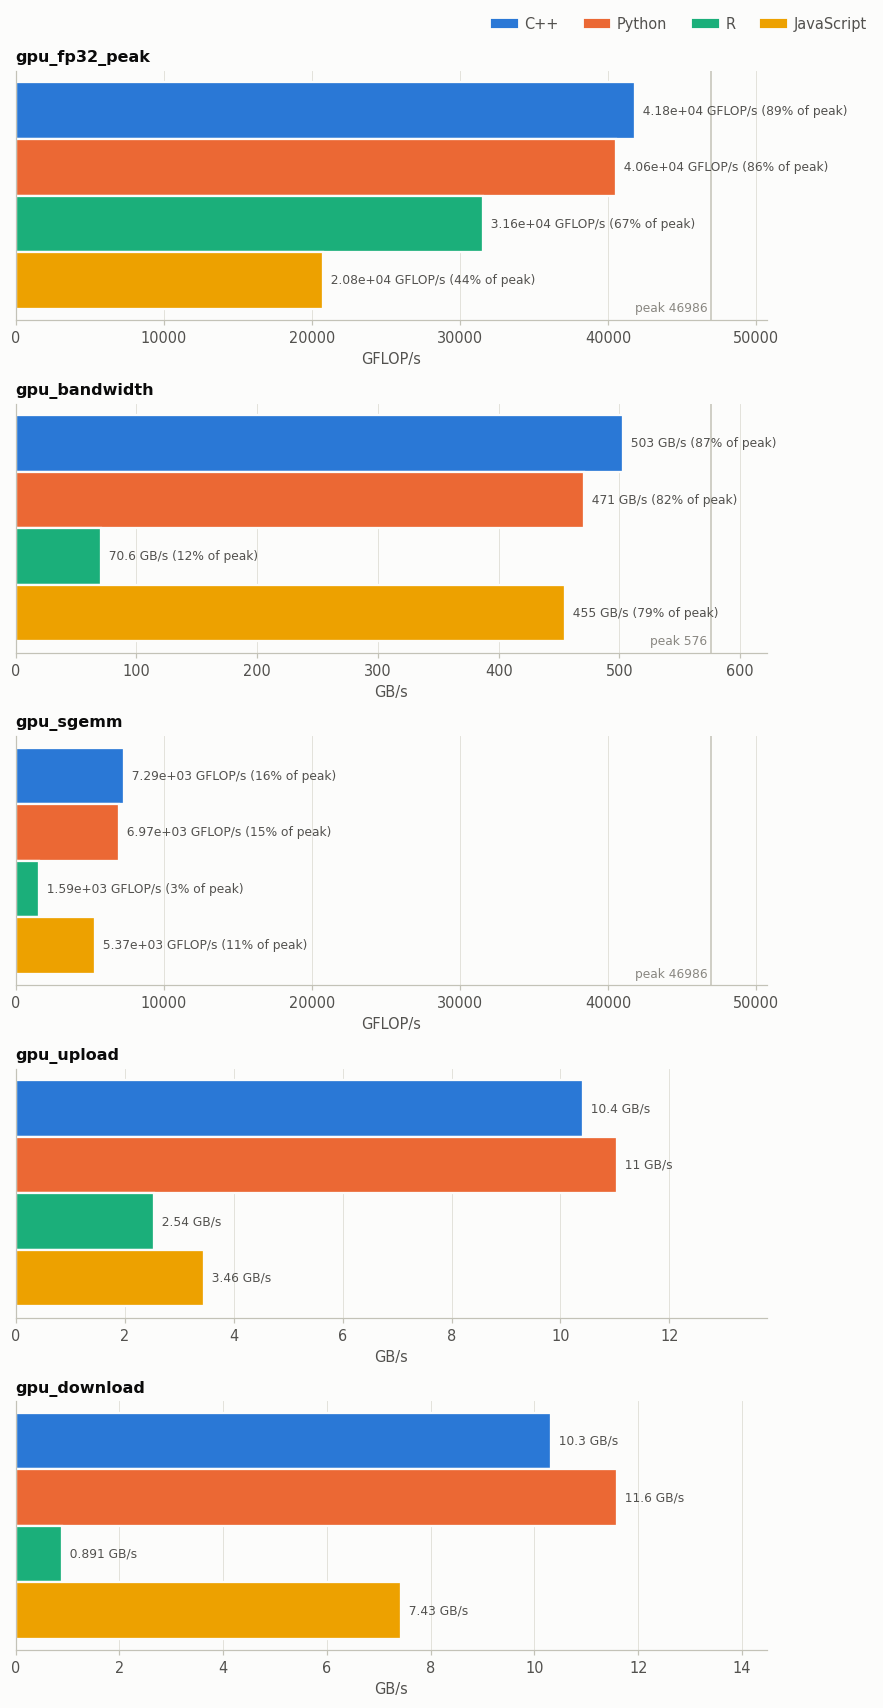

,unit,C++,Python,R,JavaScript,Python xC++,R xC++,JavaScript xC++
test,,,,,,,,
gpu_fp32_peak,GFLOP/s,"41,824","40,576","31,566","20,782",0.97,0.755,0.497
gpu_bandwidth,GB/s,503,471,70.6,455,0.936,0.14,0.904
gpu_sgemm,GFLOP/s,"7,287","6,974","1,594","5,368",0.957,0.219,0.737
gpu_upload,GB/s,10.4,11,2.54,3.46,1.06,0.244,0.332
gpu_download,GB/s,10.3,11.6,0.891,7.43,1.12,0.0864,0.72


In [12]:
gpu_tests = [t for t in TEST_ORDER if test_cat[t] == "gpu" and t in rate_by.index]
if not gpu_tests:
    print("No GPU results. Check `skipped` in the table of section 2 (OpenCL driver installed? RUSTICL_ENABLE=radeonsi?).")
else:
    gpu_langs = [l for l in langs if rate_by.loc[gpu_tests, l].notna().any()]
    missing = [l for l in langs if l not in gpu_langs]
    if missing:
        print("No GPU results for:", ", ".join(missing))
    fig, axes = plt.subplots(len(gpu_tests), 1, figsize=(8, 1.25 * len(gpu_tests) * max(len(gpu_langs), 2) / 2 + 0.6 * len(gpu_tests)),
                             squeeze=False)
    for ax, t in zip(axes.flat, gpu_tests):
        unit = tests_spec.set_index("test").unit[t]
        scale, label = DISPLAY[unit]
        peak = PEAK["gpu_fp32_gflops"] if unit == "FLOP" else (PEAK["gpu_mem_gbs"] if t == "gpu_bandwidth" else None)
        hbar_groups(ax, [t], gpu_langs, lambda _, l: rate_by.loc[t, l] / scale,
                    label_of=lambda _, l, v: f"{v:.3g} {label}" + (f" ({100 * v / peak:.0f}% of peak)" if peak and np.isfinite(peak) else ""))
        if peak is not None and np.isfinite(peak):
            peak_line(ax, peak, f"peak {peak:.0f}")
            ax.set_xlim(0, peak * 1.08)
        ax.set_yticks([]); ax.set_title(t); ax.set_xlabel(label)
    finish_layout(fig, gpu_langs); plt.show()
    rate_table(gpu_tests)

## 8. How much of the hardware each language can use

Best measured rate as a percentage of the theoretical peak (section 2). 100% is not reachable in practice —
for the CPU, the peak assumes every core at maximum boost, which laptop chips can't sustain.

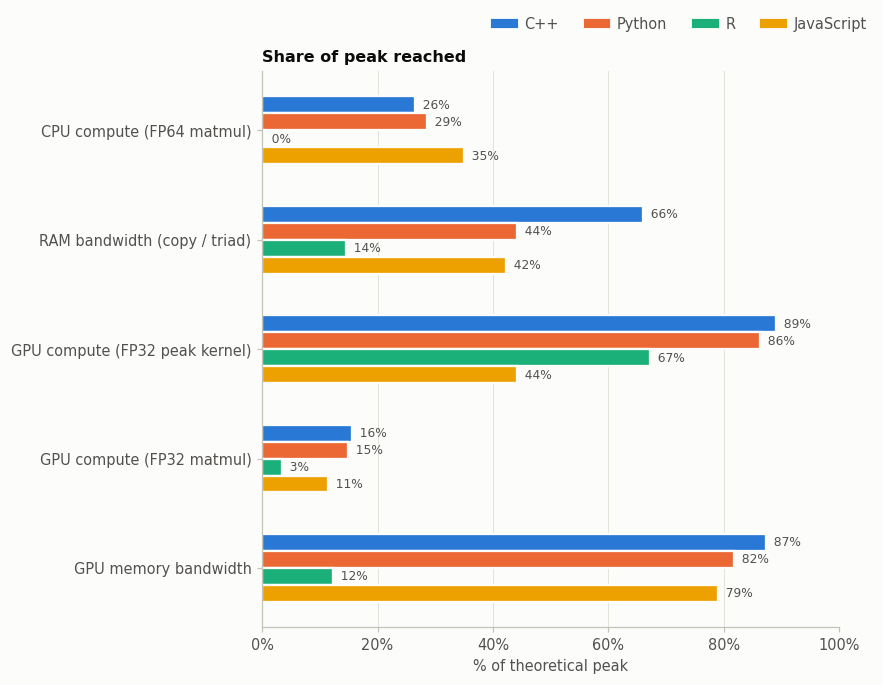

,C++ %,Python %,R %,JavaScript %
CPU compute (FP64 matmul),26.5,28.6,0.3,34.9
RAM bandwidth (copy / triad),66.1,44.2,14.4,42.2
GPU compute (FP32 peak kernel),89.0,86.4,67.2,44.2
GPU compute (FP32 matmul),15.5,14.8,3.4,11.4
GPU memory bandwidth,87.4,81.7,12.3,79.0


In [13]:
def best_rate(tests, l):
    vals = [rate_by.loc[t, l] for t in tests if t in rate_by.index and np.isfinite(rate_by.loc[t, l])]
    return max(vals) if vals else np.nan

UTIL = [("CPU compute (FP64 matmul)", ["matmul_blas"], 1e9, PEAK["cpu_fp64_gflops"]),
        ("RAM bandwidth (copy / triad)", ["mem_copy", "mem_triad"], 1e9, PEAK["ram_gbs"]),
        ("GPU compute (FP32 peak kernel)", ["gpu_fp32_peak"], 1e9, PEAK["gpu_fp32_gflops"]),
        ("GPU compute (FP32 matmul)", ["gpu_sgemm"], 1e9, PEAK["gpu_fp32_gflops"]),
        ("GPU memory bandwidth", ["gpu_bandwidth"], 1e9, PEAK["gpu_mem_gbs"])]
util = pd.DataFrame({l: {name: 100 * best_rate(ts, l) / s / p for name, ts, s, p in UTIL} for l in langs})
util = util.dropna(how="all")
fig, ax = plt.subplots(figsize=(8, 0.5 * len(util) * max(len(langs), 2) / 2 + 1.2))
hbar_groups(ax, list(util.index), langs, lambda g, l: util.loc[g, l], label_of=lambda g, l, v: f"{v:.0f}%")
ax.set_xlim(0, 100); ax.set_xlabel("% of theoretical peak")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Share of peak reached")
finish_layout(fig, langs); plt.show()
display(util.round(1).rename(columns=lambda c: f"{c} %"))

## 9. Consistency between repetitions

Coefficient of variation (standard deviation ÷ mean) of the repeated timings of each test. Under ~5% is steady;
large values usually mean thermal throttling, background activity or very short timings.

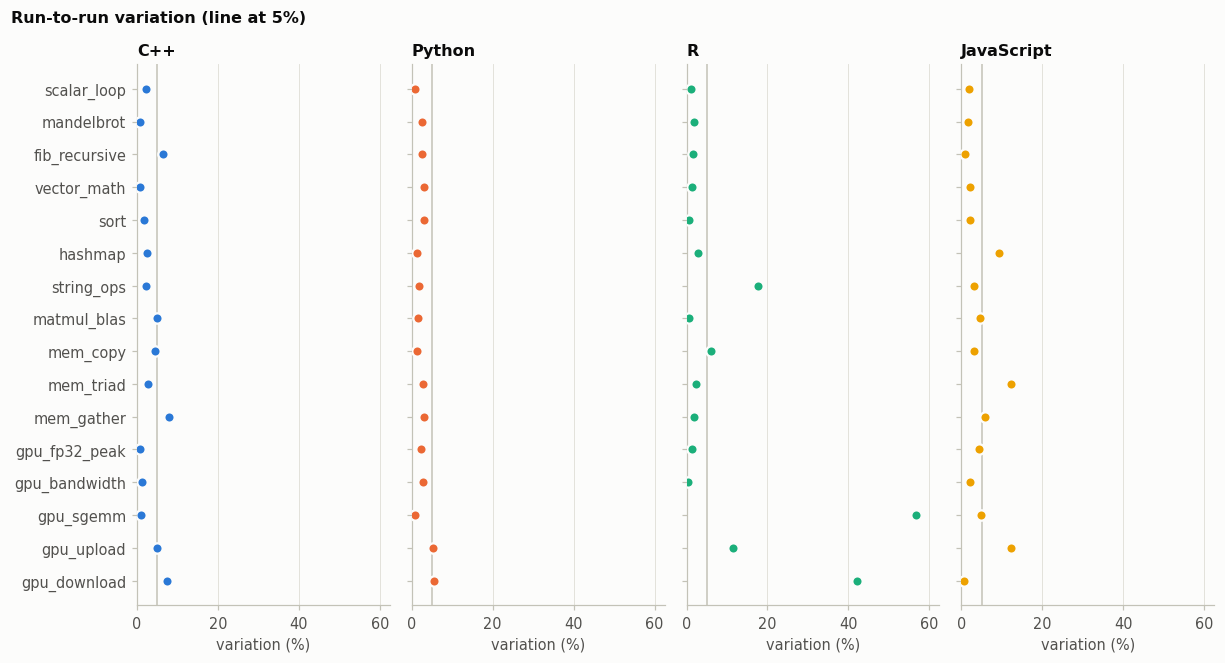

In [14]:
cv = med[med.cv.notna()].groupby(["test", "language"]).cv.max().unstack().reindex(columns=langs)
cv = cv.reindex([t for t in TEST_ORDER if t in cv.index])
if cv.empty:
    print("Only one repetition per test (e.g. verify mode) - nothing to show.")
else:
    xmax = max(10, np.nanmax(100 * cv.values) * 1.1)
    fig, axes = plt.subplots(1, len(langs), figsize=(2.4 * len(langs) + 1.6, 0.3 * len(cv) + 1.3),
                             sharey=True, squeeze=False)
    for ax, l in zip(axes.flat, langs):          # one panel per language (small multiples)
        ax.scatter(100 * cv[l], range(len(cv)), s=46, color=COLORS[l], edgecolors=SURFACE, linewidths=1.5, zorder=3)
        ax.axvline(5, color=AXIS, lw=1)
        ax.set_xlim(0, xmax); ax.set_title(l); ax.grid(axis="y", visible=False)
        ax.set_xlabel("variation (%)")
    axes[0, 0].set_yticks(range(len(cv)), cv.index); axes[0, 0].invert_yaxis()
    fig.suptitle("Run-to-run variation (line at 5%)", x=0.01, ha="left", fontweight="bold", fontsize=10.5, color=INK)
    plt.tight_layout(); plt.show()

## 10. Temperature and clock speed during the runs

From the sensor log written by `run_all.sh` (one sample per second). Shaded spans show which language was running.
A rising temperature with a falling clock is thermal throttling.

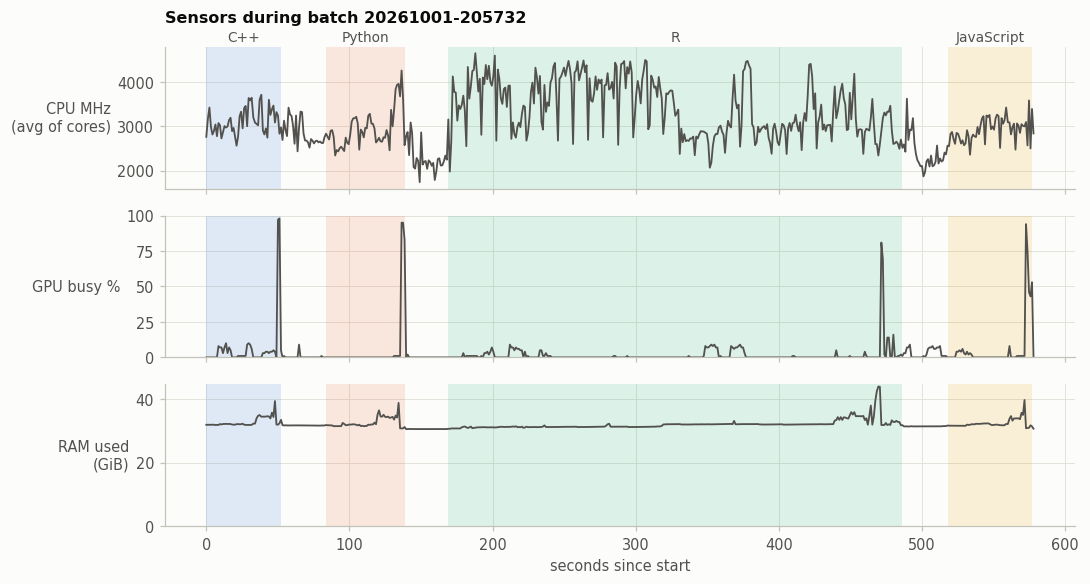

,seconds,max_cpu_temp_c,avg_cpu_mhz,max_gpu_busy_pct,max_ram_gib
phase,,,,,
C++,52.2,NaN,3105.8,98,39.3
JavaScript,59.0,NaN,2914.4,94,39.6
Python,54.8,NaN,2938.6,95,38.8
R,317.2,NaN,3410.0,81,43.9


In [15]:
folders = sorted(set(data.folder))
sensor_files = [Path(f) / f"sensors_{b}.csv" for f in folders for b in sorted(set(chosen.batch.dropna()))]
sensor_files = [p for p in sensor_files if p.exists()]
if not sensor_files:
    print("No sensor log for these runs (they were not started through run_all.sh).")
for path in sensor_files:
    s = pd.read_csv(path)
    if s.empty:
        continue
    s["t"] = s.time - s.time.iloc[0]
    panels = [("cpu_temp_c", "CPU °C", None), ("cpu_mhz_avg", "CPU MHz\n(avg of cores)", None),
              ("gpu_busy_pct", "GPU busy %", (0, 100)), ("mem_used_gib", "RAM used\n(GiB)", "zero")]
    panels = [(c, lab, lim) for c, lab, lim in panels if c in s and s[c].notna().any()]
    fig, axes = plt.subplots(len(panels), 1, figsize=(10, 1.6 * len(panels) + 0.6), sharex=True, squeeze=False)
    phase_runs = (s.phase != s.phase.shift()).cumsum()
    for ax, (col, lab, lim) in zip(axes.flat, panels):
        ax.plot(s.t, s[col], color=INK2, lw=1.2)
        if lim == "zero":
            ax.set_ylim(bottom=0)
        elif lim:
            ax.set_ylim(*lim)
        ax.set_ylabel(lab, rotation=0, ha="right", va="center")
        for _, seg in s.groupby(phase_runs):
            name = PHASE_NAMES.get(seg.phase.iloc[0])
            if name:
                ax.axvspan(seg.t.iloc[0], seg.t.iloc[-1], color=COLORS[name], alpha=0.14, lw=0)
    top = axes.flat[0]
    for _, seg in s.groupby(phase_runs):
        name = PHASE_NAMES.get(seg.phase.iloc[0])
        if name:
            top.text((seg.t.iloc[0] + seg.t.iloc[-1]) / 2, 1.02, name, transform=top.get_xaxis_transform(),
                     ha="center", va="bottom", color=INK2, fontsize=9)
    axes.flat[-1].set_xlabel("seconds since start")
    top.set_title(f"Sensors during batch {path.stem.replace('sensors_', '')}", pad=16)
    plt.tight_layout(); plt.show()
    summary = s[s.phase.isin(PHASE_NAMES)].groupby("phase").agg(
        seconds=("t", lambda t: t.max() - t.min()), max_cpu_temp_c=("cpu_temp_c", "max"),
        avg_cpu_mhz=("cpu_mhz_avg", "mean"), max_gpu_busy_pct=("gpu_busy_pct", "max"), max_ram_gib=("mem_used_gib", "max"))
    display(summary.rename(index=PHASE_NAMES).round(1))

## 11. Key findings
Generated from the numbers above.

In [16]:
lines = []
others = [l for l in langs if l != REF]
for l in others:
    lines.append(f"- **{l} overall: {overall[l]:.2g}× {REF}** "
                 + "(" + ", ".join(f"{CAT_TITLES[c]} {cat_score.loc[c, l]:.2g}×" for c in cat_score.index if np.isfinite(cat_score.loc[c, l])) + ").")
    r = ratio[l].dropna()
    if len(r):
        slow, fast = r.idxmin(), r.idxmax()
        lines.append(f"  - Biggest gap: `{slow}` at {r[slow]:.2g}× ({1 / r[slow]:.0f}× slower). "
                     f"Closest: `{fast}` at {r[fast]:.2g}×.")
loop_tests = [t for t in ratio.index if tests_spec.set_index("test")["style"][t] == "loop"]
lib_tests = [t for t in ratio.index if tests_spec.set_index("test")["style"][t] in ("vectorized", "builtin", "blas")
             and test_cat[t] != "gpu"]
for l in others:
    a, b = gmean(ratio.loc[loop_tests, l]), gmean(ratio.loc[lib_tests, l])
    if np.isfinite(a) and np.isfinite(b):
        gain = (f"handing work to optimised libraries is worth ~{b / a:.0f}×." if b / a >= 1.5 else
                "plain loops are already about as fast as library code (they are compiled, e.g. by a JIT).")
        lines.append(f"- {l}: plain loops run at {a:.2g}× {REF}, library / vectorized code at {b:.2g}× — {gain}")
if not pm.empty:
    sp = pm.loc[pm.groupby("language").speedup.idxmax()].set_index("language")
    lines.append("- Parallel speedup (best): " + ", ".join(f"{l} {sp.speedup[l]:.1f}× with {int(sp.threads[l])} workers" for l in langs if l in sp.index)
                 + f" on {PHYS} physical cores.")
for name in util.index:
    row = util.loc[name].dropna()
    if len(row):
        lines.append(f"- {name}: best {row.max():.0f}% of peak ({row.idxmax()}).")
display(Markdown("\n".join(lines)))

- **Python overall: 0.34× C++** (CPU, single core 0.19×, CPU, all cores 0.11×, RAM 0.65×, GPU 1×).
  - Biggest gap: `parallel_mandelbrot` at 0.011× (90× slower). Closest: `sort` at 6.3×.
- **R overall: 0.11× C++** (CPU, single core 0.076×, CPU, all cores 0.016×, RAM 0.47×, GPU 0.22×).
  - Biggest gap: `fib_recursive` at 0.0029× (341× slower). Closest: `sort` at 1.5×.
- **JavaScript overall: 0.76× C++** (CPU, single core 0.59×, CPU, all cores 0.97×, RAM 0.97×, GPU 0.6×).
  - Biggest gap: `fib_recursive` at 0.19× (5× slower). Closest: `hashmap` at 1.6×.
- Python: plain loops run at 0.025× C++, library / vectorized code at 0.78× — handing work to optimised libraries is worth ~31×.
- R: plain loops run at 0.019× C++, library / vectorized code at 0.22× — handing work to optimised libraries is worth ~11×.
- JavaScript: plain loops run at 0.62× C++, library / vectorized code at 0.79× — plain loops are already about as fast as library code (they are compiled, e.g. by a JIT).
- Parallel speedup (best): C++ 15.5× with 32 workers, Python 6.1× with 24 workers, R 12.6× with 24 workers, JavaScript 10.5× with 24 workers on 24 physical cores.
- CPU compute (FP64 matmul): best 35% of peak (JavaScript).
- RAM bandwidth (copy / triad): best 66% of peak (C++).
- GPU compute (FP32 peak kernel): best 89% of peak (C++).
- GPU compute (FP32 matmul): best 16% of peak (C++).
- GPU memory bandwidth: best 87% of peak (C++).

## 12. Compare machines

Every machine in `results/` (newest run of each language, same mode). Speeds are relative to the machine analysed
above (`MACHINE`): 2× means twice as fast for that language. Results are only comparable when machines ran the same
version of the tests (`suite_tests_sha` in the table).

,alienware-m16-r1,dell-inc-inspiron-14-7425-2-in-1
product,Alienware m16 R1,Inspiron 14 7425 2-in-1
cpu,13th Gen Intel(R) Core(TM) i9-13900HX,AMD Ryzen 5 5625U with Radeon Graphics
physical_cores,24,6
cpu_max_mhz,5283,4390
ram_gib,63.7,61.2
ram_type,DDR5,DDR4
ram_speed_mts,5200,3200
gpus,NVIDIA GeForce RTX 4090 Laptop GPU;Intel(R) UH...,"Advanced Micro Devices, Inc. [AMD/ATI] Barcelo..."
os,Windows 11 Home 25H2,Ubuntu 26.04.1 LTS
suite_tests_sha,96c2e949ae9d,96c2e949ae9d


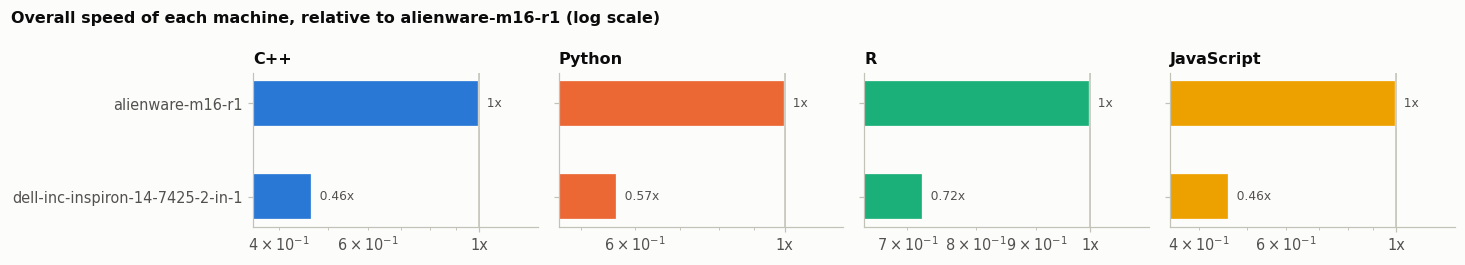

machine,alienware-m16-r1,dell-inc-inspiron-14-7425-2-in-1
overall vs alienware-m16-r1,,
C++,1x,0.465x
JavaScript,1x,0.459x
Python,1x,0.566x
R,1x,0.722x


machine                     alienware-m16-r1 dell-inc-inspiron-14-7425-2-in-1
language   category                                                          
C++        CPU, all cores                 1x                           0.654x
           CPU, single core               1x                           0.838x
           GPU                            1x                           0.107x
           RAM                            1x                           0.794x
JavaScript CPU, all cores                 1x                           0.625x
           CPU, single core               1x                           0.839x
           GPU                            1x                           0.119x
           RAM                            1x                            0.71x
Python     CPU, all cores                 1x                           0.688x
           CPU, single core               1x                            1.01x
           GPU                            1x                           0.103x
           RAM                            1x                            1.43x
R          CPU, all cores                 1x                            3.66x
           CPU, single core               1x                           0.684x
           GPU                            1x                           0.189x
           RAM                            1x                           0.572x

,alienware-m16-r1,dell-inc-inspiron-14-7425-2-in-1
overall vs C++ on the same machine,,
C++,1x,1x
Python,0.342x,0.416x
R,0.106x,0.165x
JavaScript,0.761x,0.751x


In [17]:
cmp_runs = runs[runs["mode"] == mode].sort_values("started").groupby(["machine", "language"]).tail(1)
machines = sorted(set(cmp_runs.machine), key=lambda m: (m != machine, m))   # analysed machine first
if len(machines) < 2:
    print(f"Only one machine ({machine}) has '{mode}' results so far. Run ./run_all.sh on another computer, "
          "then add its results/<machine>/ folder here (for example through the git repository).")
else:
    hw_keys = ["product", "cpu", "physical_cores", "cpu_max_mhz", "ram_gib", "ram_type", "ram_speed_mts", "gpus", "os", "suite_tests_sha"]
    display(pd.DataFrame({m: {k: system_of(m).get(k, "") or "-" for k in hw_keys} for m in machines}))
    shas = {system_of(m).get("suite_tests_sha") for m in machines} - {None, ""}
    if len(shas) > 1:
        print("Warning: machines ran different versions of tests.csv / kernels (suite_tests_sha differs); "
              "their rates may not be comparable.")

    cmp = rows[rows.run_key.isin(cmp_runs.run_key)]
    cmed = cmp.groupby(["machine", "language", "test", "threads", "size"], as_index=False).rate.median()
    cbest = cmed.groupby(["machine", "language", "test"]).rate.max().unstack("machine")[machines]
    rel = cbest.div(cbest[machine], axis=0).reset_index()           # speed vs the analysed machine
    rel["category"] = rel.test.map(test_cat)
    by_cat = rel.groupby(["language", "category"])[machines].agg(gmean)
    overall_m = by_cat.groupby(level="language").agg(gmean)
    cl = [l for l in LANGS if l in overall_m.index]

    fig, axes = plt.subplots(1, len(cl), figsize=(2.9 * len(cl) + 1.8, 0.45 * len(machines) + 1.5),
                             sharey=True, squeeze=False)
    y = np.arange(len(machines))
    for ax, l in zip(axes.flat, cl):                # one panel per language (colour = language)
        vals = overall_m.loc[l, machines].astype(float)
        ax.barh(y, vals, height=0.5, color=COLORS[l], edgecolor=SURFACE, linewidth=1.5)
        for yi, v in zip(y, vals):
            if np.isfinite(v):
                ax.text(v, yi, f"  {v:.2g}x", va="center", fontsize=8, color=INK2)
        ax.set_xscale("log"); ax.axvline(1, color=AXIS, lw=1); ax.margins(x=0.35)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
        ax.set_title(l); ax.grid(axis="y", visible=False)
    axes[0, 0].set_yticks(y, machines); axes[0, 0].invert_yaxis()
    fig.suptitle(f"Overall speed of each machine, relative to {machine} (log scale)",
                 x=0.01, ha="left", fontweight="bold", fontsize=10.5, color=INK)
    plt.tight_layout(); plt.show()

    display(overall_m[machines].map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-")
              .rename_axis(f"overall vs {machine}"))
    display(by_cat[machines].map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-")
              .rename(index=CAT_TITLES, level="category"))

    # How far each language is from C++ on each machine (does the gap change with the hardware?)
    gap = {}
    for m in machines:
        b = cbest[m].unstack("language")
        if "C++" not in b:
            continue
        r = b.div(b["C++"], axis=0)
        cat = pd.DataFrame({c: r[r.index.map(test_cat) == c].apply(gmean) for c in CATEGORIES}).T.dropna(how="all")
        gap[m] = cat.apply(gmean)
    if gap:
        display(pd.DataFrame(gap)[list(gap)].reindex(LANGS).dropna(how="all")
                  .map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-").rename_axis("overall vs C++ on the same machine"))